In [1]:
# Titanic 연습

In [2]:
import sys

sys.path.append(r'C:\임시 폴더')

from jussam import load_data
# from helper212 import *
# from helper224 import *
# from helper230 import *
from helper236 import *
from IPython.display import display , Markdown

from pandas import DataFrame , crosstab

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


In [3]:
원본 = load_data('titanic')

원본.head()

📚 타이타닉호 침몰은 역사상 가장 악명 높은 난파 사고 중 하나입니다. 1912년 4월 15일, 첫 항해 중이던 타이타닉호는 빙산과 충돌하여 침몰했습니다. 당시 배에는 모든 승객과 승무원을 태울 수 있는 구명보트가 충분하지 않아 2,224명의 승객과 승무원 중 1,502명이 목숨을 잃었습니다. 생존에는 어느 정도 운이 작용했지만, 일부 집단은 다른 집단보다 생존 가능성이 더 높았던 것으로 보입니다. 이번 과제에서는 승객 데이터(예: 이름, 나이, 성별, 사회경제적 계층 등)를 사용하여 `어떤 유형의 사람들이 생존할 가능성이 더 높았을까?`라는 질문에 답하는 예측 모델을 구축해야 합니다. (출처: https://www.kaggle.com/datasets/yasserh/titanic-dataset)

변수명       설명
-----------  -------------------------------------------------------
PassengerId  탑승객의 ID(인덱스와 같은 개념)
Survived     생존유무(0은 사망 1은 생존)
Pclass       객실의 등급(1=1등급, 2=2등급, 3=3등급)
Name         이름
Sex          성별
SibSp        동승한 형제 혹은 배우자의 수
Parch        동승한 자녀 혹은 부모의 수
Ticket       티켓번호
Fare         요금
Cabin        선실
Embarked     탑승지 (C = Cherbourg, Q = Queenstown, S = Southampton)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


In [4]:
# 이거 반영한 시각화 결과는 추후에 모듈에 반영 예정임
# 딕셔너리를 안 받은 경우 / 받은 경우 나누어서 제목을 다르게 주면 될 듯 함

# 칼럼 의미 정리
칼럼_의미 = {
    'PassengerId' :    '탑승객 식별자' ,
    'Survived' :    '생존유무 (0 = 사망 , 1 = 생존)' ,
    'Pclass' :  '객실 등급 (1 = 1등급, 2 = 2등급, 3 = 3등급)' ,
    'Name' : '이름' ,
    'Sex' : '성별' ,
    'Age' : '나이' ,
    'SibSp' : '동승한 형제 혹은 배우자의 수' ,
    'Parch' : '동승한 자녀 혹은 부모의 수' ,
    'Ticket' : '티켓번호' ,
    'Fare' : '요금' ,
    'Cabin' : '선실 번호' ,
    'Embarked' : '탑승 항구 (C = Cherbourg, Q = Queenstown, S = Southampton)'
}

칼럼_의미

{'PassengerId': '탑승객 식별자',
 'Survived': '생존유무 (0 = 사망 , 1 = 생존)',
 'Pclass': '객실 등급 (1 = 1등급, 2 = 2등급, 3 = 3등급)',
 'Name': '이름',
 'Sex': '성별',
 'Age': '나이',
 'SibSp': '동승한 형제 혹은 배우자의 수',
 'Parch': '동승한 자녀 혹은 부모의 수',
 'Ticket': '티켓번호',
 'Fare': '요금',
 'Cabin': '선실 번호',
 'Embarked': '탑승 항구 (C = Cherbourg, Q = Queenstown, S = Southampton)'}

In [5]:
원본.info()

# 1309 개 보다 적은 게 존재

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(2), int64(5), object(1), str(4)
memory usage: 166.2+ KB


In [6]:
# 관측치 행

print(f'관측치 행은 {원본.shape[0]} 개')

관측치 행은 1309 개


In [7]:
# 몇 개의 칼럼

print(f'칼럼 개수는 {원본.shape[1]} 개')

칼럼 개수는 12 개


In [8]:
df = my_EDA.결측치_중복_전처리(원본)

# 중복만 확인 후 전처리 됨
df.shape[0]

,결측치 개수,결측치 비율 (%)
PassengerId,0,0.000
Survived,0,0.000
Pclass,0,0.000
Name,0,0.000
Sex,0,0.000
Age,263,20.092
SibSp,0,0.000
Parch,0,0.000
Ticket,0,0.000
Fare,1,0.076


중복된 행의 수는 0
결측치 점검 및 중복 전처리 완료됨!!



1309

In [9]:
# 아무래도 불필요한 변수를 제거 해야 겠다

df0 = my_EDA.특정_칼럼_지우기(원본 , ['PassengerId' , 'Name' , 'Ticket' , 'Cabin'])

# 이제 칼럼 개수가 8 개로 바뀜
df0.shape[1]

8

In [10]:
종속변수 = 'Survived'
카테고리_모음 = ['Survived' , 'Pclass' , 'Sex' , 'Embarked']

df1 = my_EDA.카테고리_임의_변환(df0 , 카테고리_모음)

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  1309 non-null   category
 1   Pclass    1309 non-null   category
 2   Sex       1309 non-null   category
 3   Age       1046 non-null   float64 
 4   SibSp     1309 non-null   int64   
 5   Parch     1309 non-null   int64   
 6   Fare      1308 non-null   float64 
 7   Embarked  1307 non-null   category
dtypes: category(4), float64(2), int64(2)
memory usage: 46.2 KB


None

In [11]:
# 이제 다시 결측치 확인
# 중복의 경우 개수는 확인하되 drop 은 X 
# (고유값이 사라져서 중복 판단 불가능)

df2 = my_EDA.결측치_중복_전처리(df1 , 중복_drop여부 = False)

# 모든 행은 유지됨

df2.shape[0]

,결측치 개수,결측치 비율 (%)
Survived,0,0.000
Pclass,0,0.000
Sex,0,0.000
Age,263,20.092
SibSp,0,0.000
Parch,0,0.000
Fare,1,0.076
Embarked,2,0.153


중복된 행의 수는 202
결측치 점검 및 중복 전처리 완료됨!!



1309

In [12]:
# 이제 진짜 문제는 결측치인데 결측치를 따로 채워야 함

df3 = my_prep.결측치_대체(df2 , 칼럼들 = ['Age' , 'Fare'] , 방식 = 'median')
df4 = my_prep.결측치_대체(df3 , 칼럼들 = ['Embarked'] , 방식 = 'mode')

결측치 처리 방식 : 'median'

칼럼                       결측치                    대체값
Age           263 개 (20.09%)                   28.0

Fare             1 개 (0.08%)                14.4542

결측치 처리 방식 : 'mode'

칼럼                       결측치                    대체값
Embarked         2 개 (0.15%)                      S



In [13]:
# 다만 Age 의 20 % 를 한꺼번에 다른 값으로 채웠기 때문에 반드시 분포가 이상해 질 수 밖에 없음

df5 = my_EDA.결측치_중복_전처리(df4 , 중복_drop여부 = False)

# 일단 모든 행은 유지된 상태로 이어서 진행 ㄱㄱ

df5.shape[0]

,결측치 개수,결측치 비율 (%)
Survived,0,0.000
Pclass,0,0.000
Sex,0,0.000
Age,0,0.000
SibSp,0,0.000
Parch,0,0.000
Fare,0,0.000
Embarked,0,0.000


중복된 행의 수는 209
결측치 점검 및 중복 전처리 완료됨!!



1309

In [14]:
# 파생변수 생성
# FamilySize 동승자 수 계산

derived = df5.copy()

derived['FamilySize'] = derived['SibSp'] + derived['Parch'] + 1
# + 1 은 본인

# 칼럼 의미 갱신
칼럼_의미['FamilySize'] = '동승 가족 수 (SibSp + Parch + 본인)'

# 결과 확인
derived.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,male,22.000,1,0,7.250,S,2
1,1,1,female,38.000,1,0,71.283,C,2
2,1,3,female,26.000,0,0,7.925,S,1
3,1,1,female,35.000,1,0,53.100,S,2
4,0,3,male,35.000,0,0,8.050,S,1


In [15]:
# 이제 부터는 이름에서 호칭 추출 하기
# "성, 호칭. 이름" 으로 구성

title_raw = 원본['Name'].str.extract(r",\s*([^\.]+)\." , expand = False)

title_raw = title_raw.str.strip()

display(Markdown('** 원본 호칭 (통합 전 18종)**'))
display(title_raw.value_counts().rename('빈도').to_frame().T)

** 원본 호칭 (통합 전 18종)**

Name,Mr,Miss,Mrs,Master,Rev,Dr,Col,Ms,Major,Mlle,Don,Mme,Lady,Sir,Capt,the Countess,Jonkheer,Dona
빈도,757,260,197,61,8,8,4,2,2,2,1,1,1,1,1,1,1,1


In [16]:
# 의미 별 호칭 정의
# 이건 도메인 지식이 필요하니 대충 ㄱㄱ

title_map = {
    # 성인 남성 - Don(스페인) Sir(영국) Jonkheer(네덜란드) 는 남성 귀족 경칭
    "Mr" : "Mr" , "Don" : "Mr" , "Sir" : "Mr" , "Jonkheer" : "Mr" ,

    # 미혼 여성 - Mlle(프랑스) = Miss , Ms = 혼인 여부를 밝히지 않는 호칭
    "Miss" : "Miss" , "Mlle" : "Miss" , "Ms" : "Miss" ,

    # 기혼 여성 - Mme(프랑스) ·Dona(스페인)=Mrs, Lady·the Countess는 여성 귀족 경칭
    "Mrs" : "Mrs" , "Mme" : "Mrs" , "Dona" : "Mrs" , "Lady" : "Mrs" , "the Countess" : "Mrs" ,

    # 남자아이
    "Master" : "Master",

    # 전문직 군인 성직자 - 이름에 직위가 드러난 사람들
    "Dr": "Officer", "Rev": "Officer", "Col": "Officer", "Major": "Officer", "Capt": "Officer"
}

In [17]:
# Title 변수 추가
# 원본과 인덱스가 같으므로 그대로 붙음

derived['Title'] = title_raw.map(title_map)

# 매핑 누락 점검
# 결측이 1 건이라도 있으면 title_map 에 빠진 호칭이 있다는 의미
print('Title 매핑 누락 : ' , derived['Title'].isna().sum() , '건\n')

# 문자열 이므로 명목형으로 선언한다
# 그대로 두면 더미 인코딩 대상이 되지 않음
derived = my_EDA.카테고리_임의_변환(derived , 'Title')

# 칼럼 의미 사전도 함께 갱신
# 이 후 EDA 시 사전 참조 예정 <<-- 이 부분은 추후에 구현 develop
칼럼_의미['Title'] = '이름에서 추출한 호칭 (Mr / Mrs / Miss / Master / Officer)'

display(원본[['Name']].join(derived[['Title' , 'SibSp' , 'Parch' , 'FamilySize']]).head(10))
display(derived['Title'].value_counts().rename('빈도').to_frame().T)

Title 매핑 누락 :  0 건

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    1309 non-null   category
 1   Pclass      1309 non-null   category
 2   Sex         1309 non-null   category
 3   Age         1309 non-null   float64 
 4   SibSp       1309 non-null   int64   
 5   Parch       1309 non-null   int64   
 6   Fare        1309 non-null   float64 
 7   Embarked    1309 non-null   category
 8   FamilySize  1309 non-null   int64   
 9   Title       1309 non-null   category
dtypes: category(5), float64(2), int64(3)
memory usage: 57.9 KB


None

,Name,Title,SibSp,Parch,FamilySize
0,"Braund, Mr. Owen Harris",Mr,1,0,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",Mrs,1,0,2
2,"Heikkinen, Miss. Laina",Miss,0,0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,1,0,2
4,"Allen, Mr. William Henry",Mr,0,0,1
5,"Moran, Mr. James",Mr,0,0,1
6,"McCarthy, Mr. Timothy J",Mr,0,0,1
7,"Palsson, Master. Gosta Leonard",Master,3,1,5
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,0,2,3
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,1,0,2


Title,Mr,Miss,Mrs,Master,Officer
빈도,760,264,201,61,23


In [18]:
# 호칭이 정말 '신분' 을 담고 있는 지 확인

display(Markdown('** 호칭별 성별 분포 **'))
display(crosstab(derived['Title'] , derived['Sex']))

# 나이는 결측을 채우기 전인 원본 기준으로 봄
display(Markdown('** 호칭별 나이 요약 (원본 테이블 기준) **'))
display(원본.assign(Title = derived['Title']).groupby('Title' , observed = True)['Age']
        .agg(['count' , 'median' , 'min' , 'max']).T)

** 호칭별 성별 분포 **

Sex,female,male
Title,,
Master,0,61
Miss,264,0
Mr,0,760
Mrs,201,0
Officer,1,22


** 호칭별 나이 요약 (원본 테이블 기준) **

Title,Master,Miss,Mr,Mrs,Officer
count,53.000,213.000,584.000,174.000,22.000
median,4.000,22.000,29.000,35.500,49.500
min,0.330,0.170,11.000,14.000,23.000
max,14.500,63.000,80.000,76.000,70.000


In [19]:
# 호칭이 성별 및 연렁대 정보를 전부 정확히 담고 있다

기술통계량 , 명목형_기술통계량 , 카테고리_변환 , 명목형_변수 , 연속형_변수 = my_EDA.변수구분(대상 = derived , 종속변수 = 종속변수)

In [20]:
명목형_기술통계량

,Survived,Pclass,Sex,Embarked,Title
count,1309,1309,1309,1309,1309
unique,2,3,2,3,5
top,0,3,male,S,Mr
freq,815,709,843,916,760


In [21]:
기술통계량.T

,Age,SibSp,Parch,Fare,FamilySize
count,1309.000,1309.000,1309.000,1309.000,1309.000
mean,29.503,0.499,0.385,33.281,1.884
std,12.905,1.042,0.866,51.741,1.584
min,0.170,0.000,0.000,0.000,1.000
25%,22.000,0.000,0.000,7.896,1.000
50%,28.000,0.000,0.000,14.454,1.000
75%,35.000,1.000,0.000,31.275,2.000
max,80.000,8.000,9.000,512.329,11.000
평균 중앙 차이,0.054,inf,inf,1.303,0.884
차이 결과,거의 비슷함,매우 큰 차이,매우 큰 차이,매우 큰 차이,매우 큰 차이


In [22]:
명목형_변수 , 연속형_변수

(['Pclass', 'Sex', 'Embarked', 'Title'],
 ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize'])

In [23]:
# 서열 척도 적용

# 서열척도를 적용할 변수와 순서를 정의 (낮은 등급 부터 높은 등급 까지)
ordinal_map = {
    "Pclass": [3, 2, 1]
    # 3등급 < 2등급 < 1등급
}

# 서열은 없지만 더미변수의 기준 (reference) 범주를 지정하기 위해 순서만 재배치할 변수
# 맨 앞에 둔 범주가 drop_first 로 빠지면서 기준이 된다
reference_map = {
    "Title": ["Mr", "Officer", "Master", "Miss", "Mrs"]
    # 기준: Mr (성인 남성)
}

# 정의된 내용에 따라 순서를 재지정
# 이 때 데이터셋에 없는 컬럼은 건너뛰므로 
# 다른 데이터셋에서도 오류가 나지 않음
df = derived.copy()

for col, order in ordinal_map. items( ):
    if col in df.columns:
        print(f"'{col}' 컬럼 순서 재지정 (서열척도) : {order}")
        df[col] = df[col].cat.reorder_categories(order , ordered=True)

for col, order in reference_map. items( ):
    if col in df.columns:
        print(f"'{col}' 컬럼 순서 재지정 (기준 범주용) : {order}")

        # ordered = False
        # 순서만 바꿀 뿐 서열척도로 선언하지는 않는다
        df[col] = df[col].cat.reorder_categories(order , ordered=False)

'Pclass' 컬럼 순서 재지정 (서열척도) : [3, 2, 1]
'Title' 컬럼 순서 재지정 (기준 범주용) : ['Mr', 'Officer', 'Master', 'Miss', 'Mrs']


In [24]:
print(f'1. 관측치 행은 {원본.shape[0]} 개 이다.\n')
print(f'2. 칼럼 개수는 {원본.shape[1]} 개 이다.\n')

결측치점검결과 = my_qtcheck.결측치점검(원본)
결측치개수 = 결측치점검결과[결측치점검결과['결측치 개수'] > 0].count().values[0]

print(f'3. 결측치가 있는 행은 {결측치개수} 개 이다.\n')

결측치최다비율 = 결측치점검결과['결측치 비율 (%)'].idxmax()

print(f'4. 결측치 비율이 가장 높은 칼럼은 {결측치최다비율} 이다.\n')

중복개수 = 원본.duplicated().sum()

print(f'5. 원본 상태에서 중복 점검 수행 시 중복된 행은 {중복개수} 개 이다.\n')

print(f'6. 분석 대상이 아닌 칼럼을 지우고 나면 남은 칼럼은 {df0.shape[1]} 개 이다.\n')
# df0 가 불필요한 변수 4개를 제거 한 상태다.

print(f'7. Age 는 median() 방식으로 채웠기 때문에 {원본['Age'].median()} 으로 결측치 부분을 전부 채웠다.\n')

print(f'8. Embarked 는 mode() 방식으로 채웠기 때문에 {원본['Embarked'].mode().values[0]} 로 결측치 부분을 전부 채웠다.')

1. 관측치 행은 1309 개 이다.

2. 칼럼 개수는 12 개 이다.

3. 결측치가 있는 행은 4 개 이다.

4. 결측치 비율이 가장 높은 칼럼은 Cabin 이다.

5. 원본 상태에서 중복 점검 수행 시 중복된 행은 0 개 이다.

6. 분석 대상이 아닌 칼럼을 지우고 나면 남은 칼럼은 8 개 이다.

7. Age 는 median() 방식으로 채웠기 때문에 28.0 으로 결측치 부분을 전부 채웠다.

8. Embarked 는 mode() 방식으로 채웠기 때문에 S 로 결측치 부분을 전부 채웠다.


In [25]:
print(f'9. 원래는 {len(title_map)} 종류의 이름이 존재한다.\n')

print(f'10. 하지만 실제로 이름에서 나온 호칭은 {list(derived['Title'].unique())} 으로 '
      f'총 {derived['Title'].nunique()} 종류 이다')

9. 원래는 18 종류의 이름이 존재한다.

10. 하지만 실제로 이름에서 나온 호칭은 ['Mr', 'Mrs', 'Miss', 'Master', 'Officer'] 으로 총 5 종류 이다


In [26]:
최소인덱스 = derived['Title'].value_counts().idxmin()
# idxmin() 을 통해 최소값이 있는 인덱스명 추출

print(f'11. 해당 범주 중 개수가 가장 적은 것은 {최소인덱스} 이다.')

11. 해당 범주 중 개수가 가장 적은 것은 Officer 이다.


In [27]:
나이최대값 = 카테고리_변환[카테고리_변환['Title'] == 'Master']['Age'].max()

print(f'12. Master 중에서 최대 나이는 {나이최대값} 이다.\n')

print(f'13. 파생 변수 추가 후 칼럼 개수는 {카테고리_변환.shape[1]} 개 이다.')

12. Master 중에서 최대 나이는 28.0 이다.

13. 파생 변수 추가 후 칼럼 개수는 10 개 이다.


In [28]:
print(f'14. 이상치가 가장 많이 있는 항목은 {기술통계량['이상치 수'].idxmax()}')

14. 이상치가 가장 많이 있는 항목은 Parch


In [29]:
print(f'15. 왜도의 절대값이 가장 큰 항목은 {기술통계량['skew'].abs().idxmax()}')

15. 왜도의 절대값이 가장 큰 항목은 Fare


In [30]:
print(f'16. 명목형 독립변수는 {명목형_변수} 로 개수는 {len(명목형_변수)} 개 이다.\n')

print(f'17. 연속형 독립변수는 {연속형_변수} 로 개수는 {len(연속형_변수)} 개 이다.\n')

print('18. 분석 기법은 T 검정 (명목형 -> 연속형) / 교차분석 (명목형 -> 명목형) 이렇게 사용\n')

print(f'19. 서열 척도는 Places / 20. Title 범주 기준은 {derived['Title'].unique()[0]} 이다')

16. 명목형 독립변수는 ['Pclass', 'Sex', 'Embarked', 'Title'] 로 개수는 4 개 이다.

17. 연속형 독립변수는 ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize'] 로 개수는 5 개 이다.

18. 분석 기법은 T 검정 (명목형 -> 연속형) / 교차분석 (명목형 -> 명목형) 이렇게 사용

19. 서열 척도는 Places / 20. Title 범주 기준은 Mr 이다


In [31]:
# 그럼 진짜로 이상치 개수가 맞는 지 확인하러 ㄱㄱ

기술통계량['이상치 수'].sort_values(ascending = False)

Parch         307
Fare          171
FamilySize    125
Age           101
SibSp          57
Name: 이상치 수, dtype: int64

y축 세우기 (단일 플롯)
그래프를 그렸습니다


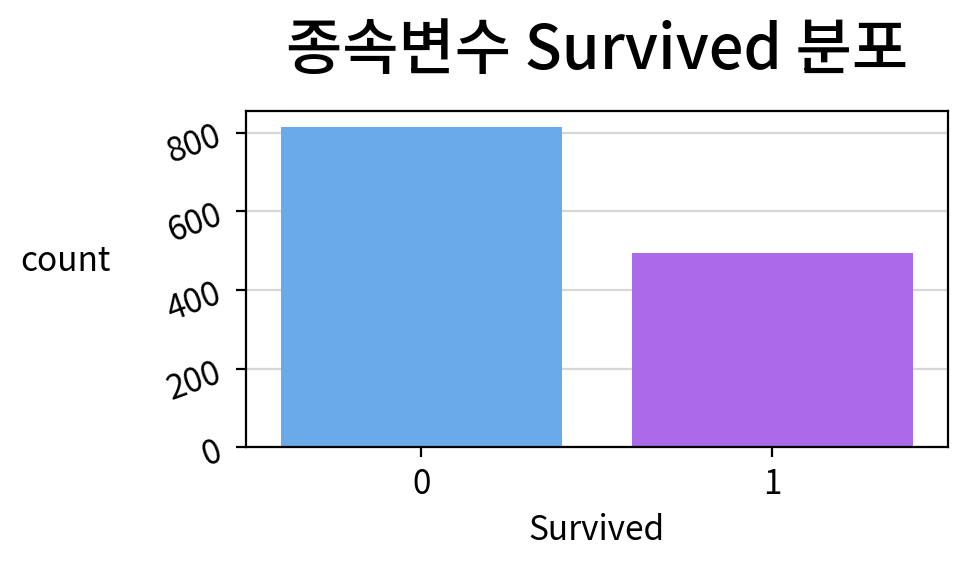

,count,unique,top,freq
Survived,1309,2,0,815


,빈도,비율
Survived,,
0,815,0.623
1,494,0.377


[경고] 종속변수 'Survived'는 불균형 분포로 판단됩니다!
 - 최소 클래스 비율: 0.38 (기준: 25.0% 미만)
 - 최대/최소 비율 격차: 1.65배 (기준: 1.5배 이상)



,독립변수명,최소비율,불균형 여부
0,Survived,0.377,True


In [32]:
기술통계량_결과 , 결과 , 빈도수 = my_EDA.종속변수_분포_확인(카테고리_변환 , 종속변수 , 가로 = 500 , 세로 = 300)

y축 세우기 (단일 플롯)
그래프를 그렸습니다


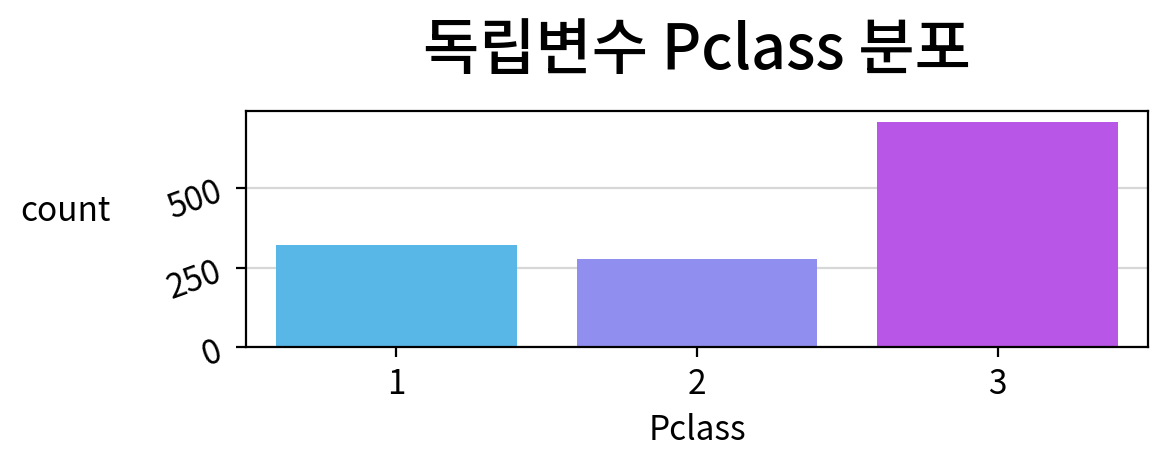

,count,unique,top,freq
Pclass,1309,3,3,709


,빈도,비율
Pclass,,
3,709,0.542
1,323,0.247
2,277,0.212


[경고] 독립변수 'Pclass'는 불균형 분포로 판단됩니다!
 - 최소 클래스 비율: 0.21 (기준: 16.7% 미만)
 - 최대/최소 비율 격차: 2.56배 (기준: 1.5배 이상)

y축 세우기 (단일 플롯)
그래프를 그렸습니다


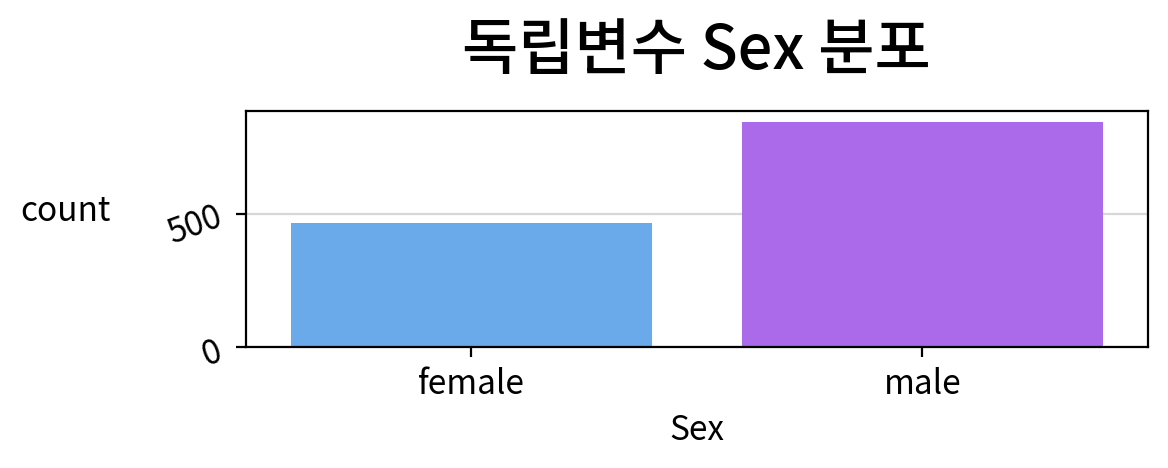

,count,unique,top,freq
Sex,1309,2,male,843


,빈도,비율
Sex,,
male,843,0.644
female,466,0.356


[경고] 독립변수 'Sex'는 불균형 분포로 판단됩니다!
 - 최소 클래스 비율: 0.36 (기준: 25.0% 미만)
 - 최대/최소 비율 격차: 1.81배 (기준: 1.5배 이상)

y축 세우기 (단일 플롯)
그래프를 그렸습니다


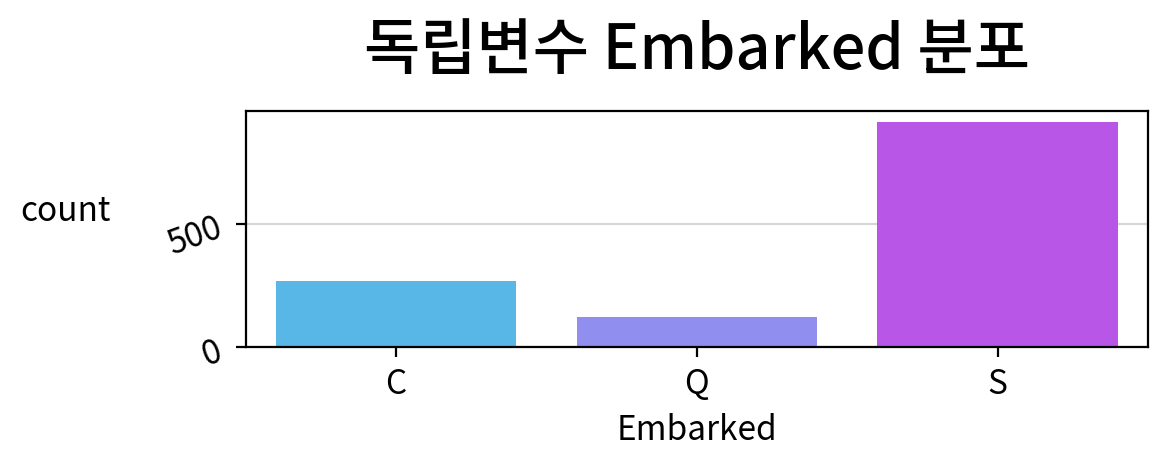

,count,unique,top,freq
Embarked,1309,3,S,916


,빈도,비율
Embarked,,
S,916,0.700
C,270,0.206
Q,123,0.094


[경고] 독립변수 'Embarked'는 불균형 분포로 판단됩니다!
 - 최소 클래스 비율: 0.09 (기준: 16.7% 미만)
 - 최대/최소 비율 격차: 7.45배 (기준: 1.5배 이상)

y축 세우기 (단일 플롯)
그래프를 그렸습니다


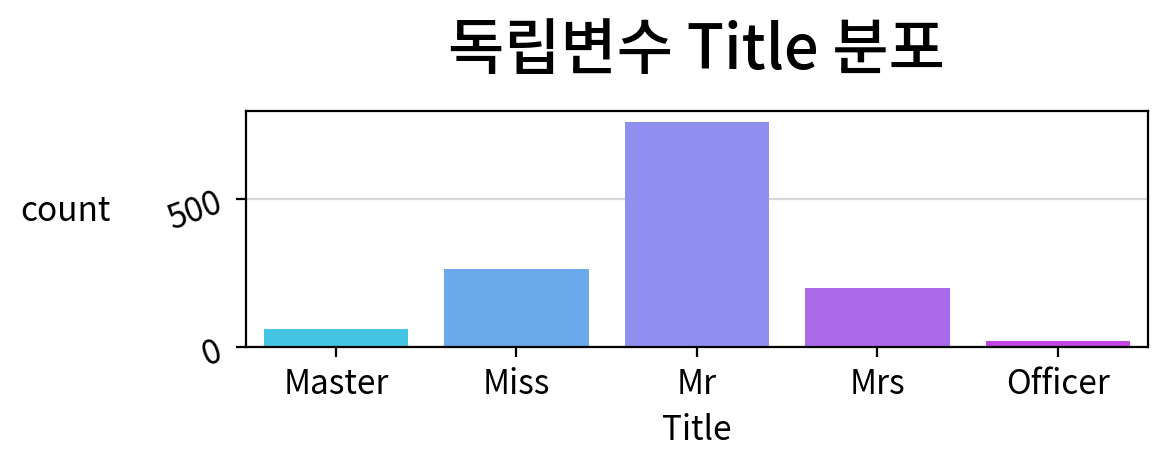

,count,unique,top,freq
Title,1309,5,Mr,760


,빈도,비율
Title,,
Mr,760,0.581
Miss,264,0.202
Mrs,201,0.154
Master,61,0.047
Officer,23,0.018


[경고] 독립변수 'Title'는 불균형 분포로 판단됩니다!
 - 최소 클래스 비율: 0.02 (기준: 10.0% 미만)
 - 최대/최소 비율 격차: 33.04배 (기준: 1.5배 이상)



,독립변수명,최소비율,불균형 여부
0,Pclass,0.212,True
0,Sex,0.356,True
0,Embarked,0.094,True
0,Title,0.018,True


In [33]:
명목형_단변량_분석_결과 , 빈도수 = my_EDA.독립변수_명목형_단변량_분석(카테고리_변환 , 명목형_변수 , 가로 = 600 , 세로 = 250)

y축 세우기 (다중 플롯)
그래프를 그렸습니다


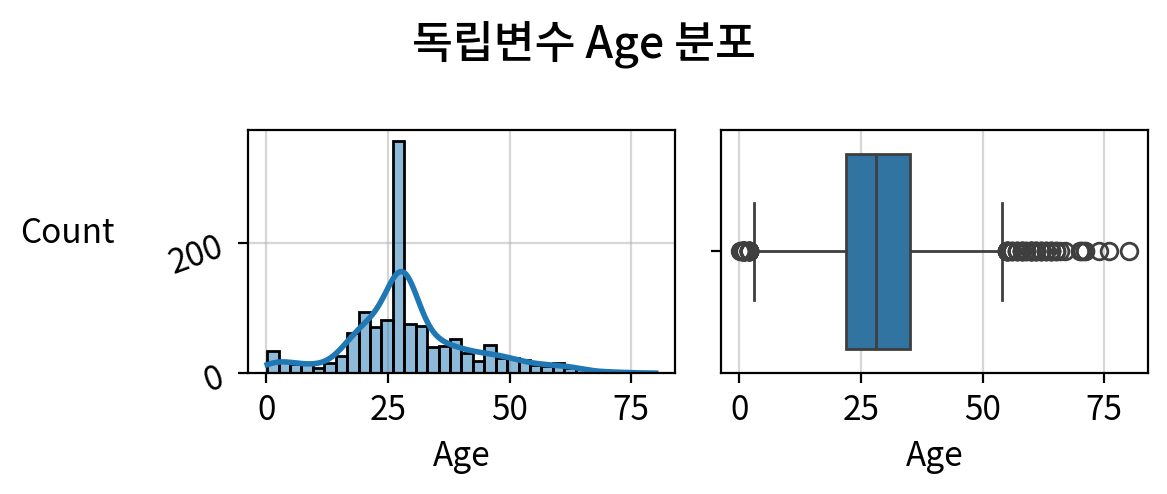

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
Age,1309.000,29.503,12.905,0.170,22.000,28.000,35.000,80.000,0.054,거의 비슷함,13.000,54.500,2.500,67,0.051,34,0.026,101,0.077,0.541,오른쪽으로 긴 꼬리,0.970,약간 쏠려있음,log


[1순위] 위치 (Peak X): 27.6753 | 밀도값: 0.0508


관찰 내용
독립변수명 점검 항목                               
Age   분포 모양 (왜도)  0.54 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                            1 개
      이상치                           7.72 %
      가장 많이 분포           27.675 에 가장 많이 분포
      로그 변환 진단결과                       log
      실제 진단결과                     로그 변환 필요

y축 세우기 (다중 플롯)
그래프를 그렸습니다


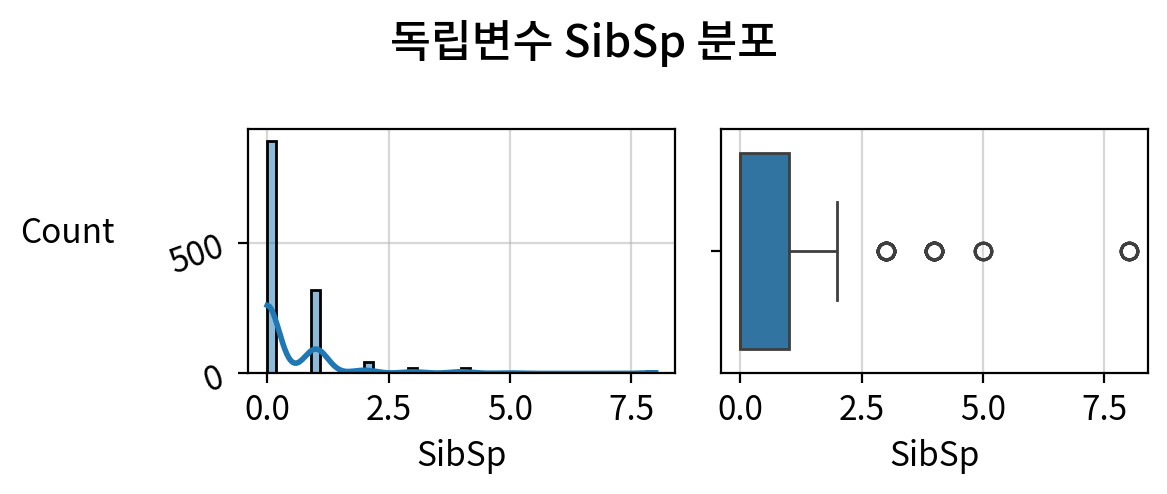

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
SibSp,1309.000,0.499,1.042,0.000,0.000,0.000,1.000,8.000,inf,매우 큰 차이,1.000,2.500,-1.500,57,0.044,0,0.000,57,0.044,3.844,오른쪽으로 긴 꼬리,20.043,약간 쏠려있음,log1p


[1순위] 위치 (Peak X): 0.0010 | 밀도값: 1.0954
[2순위] 위치 (Peak X): 1.0020 | 밀도값: 0.3924


관찰 내용
독립변수명 점검 항목                                
SibSp 분포 모양 (왜도)   3.84 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             2 개
      이상치                            4.35 %
      가장 많이 분포             0.001 에 가장 많이 분포
      2 번째로 많이 분포       1.002 에 2 번째로 많이 분포
      로그 변환 진단결과                      log1p
      실제 진단결과                 로그 더하기1 변환 필요

y축 세우기 (다중 플롯)
그래프를 그렸습니다


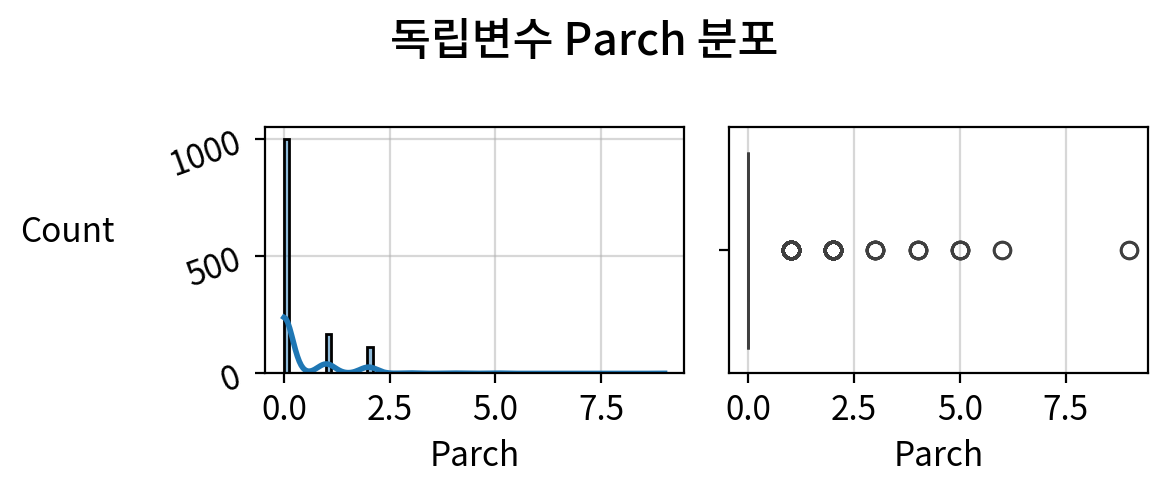

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
Parch,1309.000,0.385,0.866,0.000,0.000,0.000,0.000,9.000,inf,매우 큰 차이,0.000,0.000,0.000,307,0.235,0,0.000,307,0.235,3.669,오른쪽으로 긴 꼬리,21.541,약간 쏠려있음,log1p


[1순위] 위치 (Peak X): 0.0020 | 밀도값: 1.4822
[2순위] 위치 (Peak X): 1.0040 | 밀도값: 0.2514
[3순위] 위치 (Peak X): 1.9950 | 밀도값: 0.1671


관찰 내용
독립변수명 점검 항목                                
Parch 분포 모양 (왜도)   3.67 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                             3 개
      이상치                           23.45 %
      가장 많이 분포             0.002 에 가장 많이 분포
      2 번째로 많이 분포       1.004 에 2 번째로 많이 분포
      3 번째로 많이 분포       1.995 에 3 번째로 많이 분포
      로그 변환 진단결과                      log1p
      실제 진단결과                 로그 더하기1 변환 필요

y축 세우기 (다중 플롯)
그래프를 그렸습니다


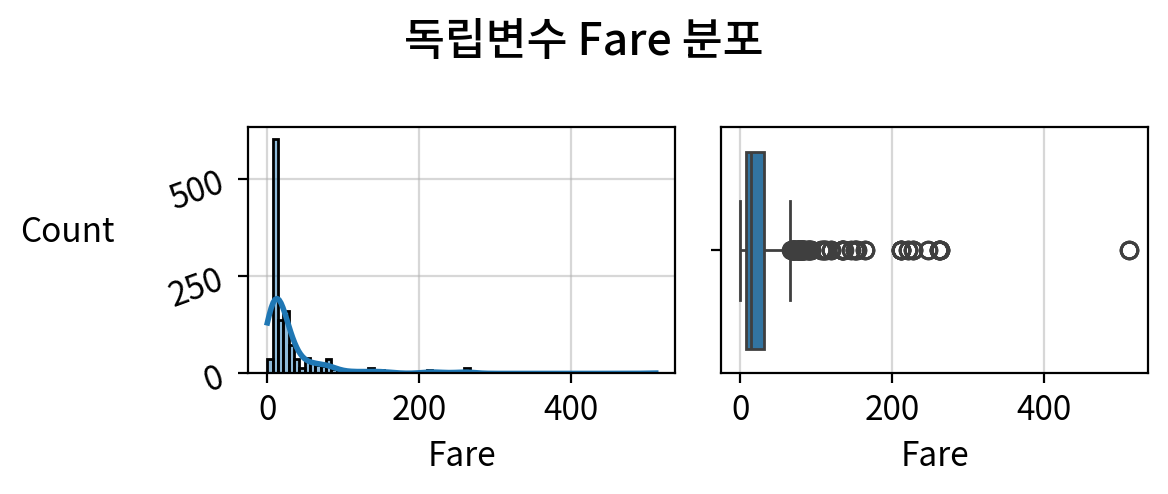

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
Fare,1309.000,33.281,51.741,0.000,7.896,14.454,31.275,512.329,1.303,매우 큰 차이,23.379,66.344,-27.173,171,0.131,0,0.000,171,0.131,4.370,오른쪽으로 긴 꼬리,27.050,약간 쏠려있음,log1p


[1순위] 위치 (Peak X): 12.3859 | 밀도값: 0.0210


관찰 내용
독립변수명 점검 항목                               
Fare  분포 모양 (왜도)  4.37 이므로 우편향 (오른쪽으로 치우침)
      봉우리 수                            1 개
      이상치                          13.06 %
      가장 많이 분포           12.386 에 가장 많이 분포
      로그 변환 진단결과                     log1p
      실제 진단결과                로그 더하기1 변환 필요

y축 세우기 (다중 플롯)
그래프를 그렸습니다


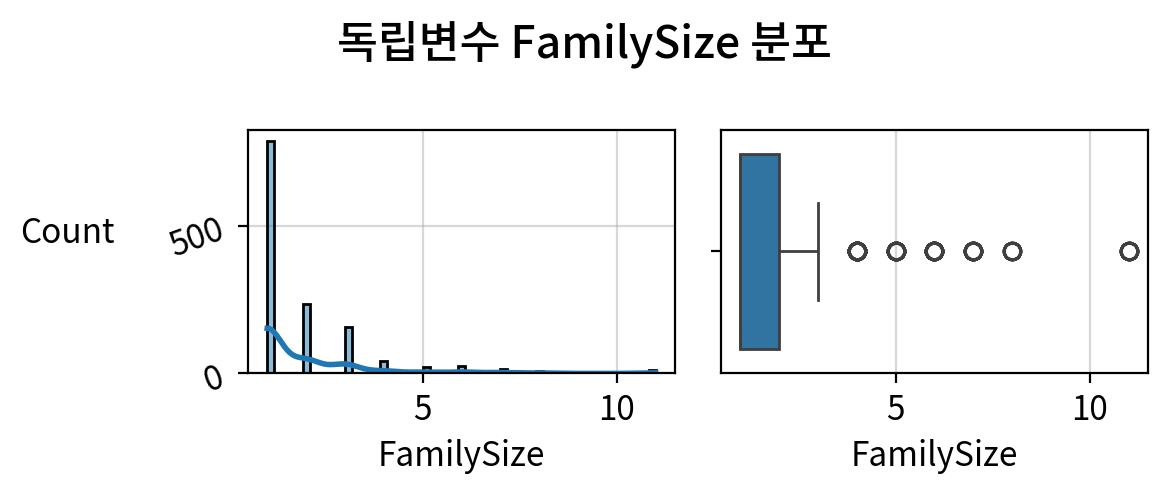

,count,mean,std,min,25%,50%,75%,max,평균 중앙 차이,차이 결과,IQR,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,이상치 수,이상치 비율,skew,왜도 결과,kurt,첨도 결과,로그 변환 필요성
FamilySize,1309.000,1.884,1.584,1.000,1.000,1.000,2.000,11.000,0.884,매우 큰 차이,1.000,3.500,-0.500,125,0.095,0,0.000,125,0.095,2.853,오른쪽으로 긴 꼬리,10.299,약간 쏠려있음,log


[1순위] 위치 (Peak X): 1.0090 | 밀도값: 0.6446


관찰 내용
독립변수명      점검 항목                               
FamilySize 분포 모양 (왜도)  2.85 이므로 우편향 (오른쪽으로 치우침)
           봉우리 수                            1 개
           이상치                           9.55 %
           가장 많이 분포            1.009 에 가장 많이 분포
           로그 변환 진단결과                       log
           실제 진단결과                     로그 변환 필요

관찰 내용
독립변수명      점검 항목                                
Age        분포 모양 (왜도)   0.54 이므로 우편향 (오른쪽으로 치우침)
           봉우리 수                             1 개
           이상치                            7.72 %
           가장 많이 분포            27.675 에 가장 많이 분포
           로그 변환 진단결과                        log
           실제 진단결과                      로그 변환 필요
SibSp      분포 모양 (왜도)   3.84 이므로 우편향 (오른쪽으로 치우침)
           봉우리 수                             2 개
           이상치                            4.35 %
           가장 많이 분포             0.001 에 가장 많이 분포
           2 번째로 많이 분포       1.002 에 2 번째로 많이 분포
           로그 변환 진단결과                      log1p
           실제 진단결과                 로그 더하기1 변환 필요
Parch      분포 모양 (왜도)   3.67 이므로 우편향 (오른쪽으로 치우침)
           봉우리 수                             3 개
           이상치                           23.45 %
           가장 많이 분포             0.002 에 가장 많이 분포
           2 번째로 많이 분포       1.004 에 2 번째로 많이 분포
           3 번째로 많이 분포       1.995 에 3 번째로 많이 분포
           로그 변환 진단결과                      log1p
           실제 진단결과                 로그 더하기1 변환 필요
Fare       분포 모양 (왜도)   4.37 이므로 우편향 (오른쪽으로 치우침)
           봉우리 수                             1 개
           이상치                           13.06 %
           가장 많이 분포            12.386 에 가장 많이 분포
           로그 변환 진단결과                      log1p
           실제 진단결과                 로그 더하기1 변환 필요
FamilySize 분포 모양 (왜도)   2.85 이므로 우편향 (오른쪽으로 치우침)
           봉우리 수                             1 개
           이상치                            9.55 %
           가장 많이 분포             1.009 에 가장 많이 분포
           로그 변환 진단결과                        log
           실제 진단결과                      로그 변환 필요

In [34]:
연속형_단변량_분석_결과 = my_EDA.독립변수_연속형_단변량_분석(카테고리_변환 , 연속형_변수 , 가로 = 600 , 세로 = 250)

#### Age -> Survived

y축 세우기 (단일 플롯)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:2.947e-01 U_stat=2.082e+05
그래프를 그렸습니다


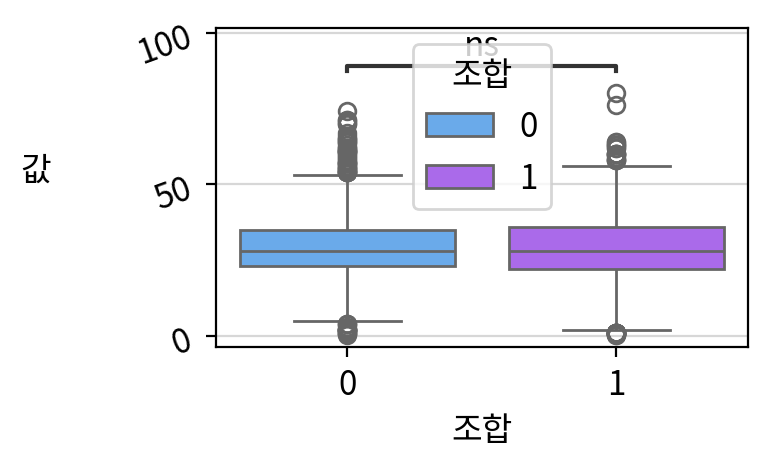

통계량  p - value  귀무가설 기각 여부  \
test                  검정 방향                                     
Mann - Whitney U test 양측    208212.000      0.295       False   
                      좌측    208212.000      0.853       False   
                      우측    208212.000      0.147       False   

                                                          결과  
test                  검정 방향                                   
Mann - Whitney U test 양측         왼쪽 집단 (0) 과 오른쪽 집단 (1) 은 같다  
                      좌측     왼쪽 집단 (0) 은 오른쪽 집단 (1) 보다 작지 않다  
                      우측     왼쪽 집단 (0) 은 오른쪽 집단 (1) 보다 크지 않다

#### SibSp -> Survived

y축 세우기 (단일 플롯)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:9.012e-05 U_stat=1.801e+05
그래프를 그렸습니다


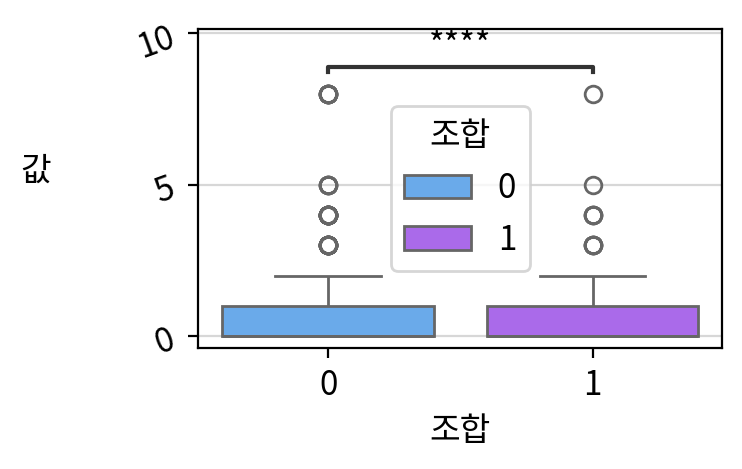

통계량  p - value  귀무가설 기각 여부  \
test                  검정 방향                                     
Mann - Whitney U test 양측    180053.500      0.000        True   
                      좌측    180053.500      0.000        True   
                      우측    180053.500      1.000       False   

                                                          결과  
test                  검정 방향                                   
Mann - Whitney U test 양측     왼쪽 집단 (0) 과 오른쪽 집단 (1) 은 차이가 난다  
                      좌측        왼쪽 집단 (0) 은 오른쪽 집단 (1) 보다 작다  
                      우측     왼쪽 집단 (0) 은 오른쪽 집단 (1) 보다 크지 않다

#### Parch -> Survived

y축 세우기 (단일 플롯)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.990e-09 U_stat=1.718e+05
그래프를 그렸습니다


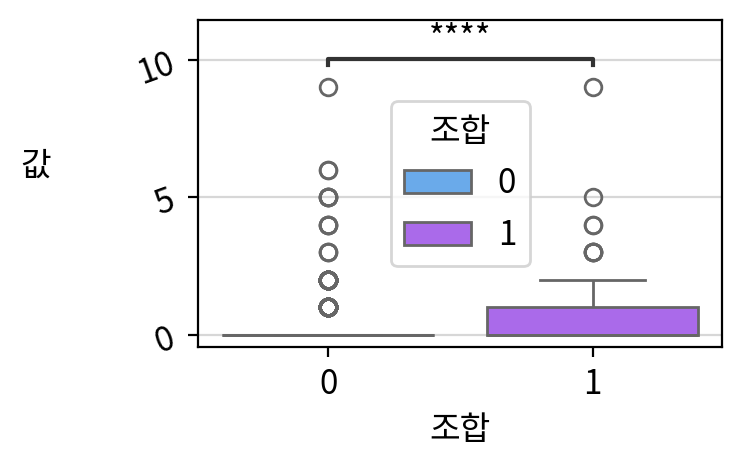

통계량  p - value  귀무가설 기각 여부  \
test                  검정 방향                                     
Mann - Whitney U test 양측    171848.000      0.000        True   
                      좌측    171848.000      0.000        True   
                      우측    171848.000      1.000       False   

                                                          결과  
test                  검정 방향                                   
Mann - Whitney U test 양측     왼쪽 집단 (0) 과 오른쪽 집단 (1) 은 차이가 난다  
                      좌측        왼쪽 집단 (0) 은 오른쪽 집단 (1) 보다 작다  
                      우측     왼쪽 집단 (0) 은 오른쪽 집단 (1) 보다 크지 않다

#### Fare -> Survived

y축 세우기 (단일 플롯)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:6.446e-25 U_stat=1.330e+05
그래프를 그렸습니다


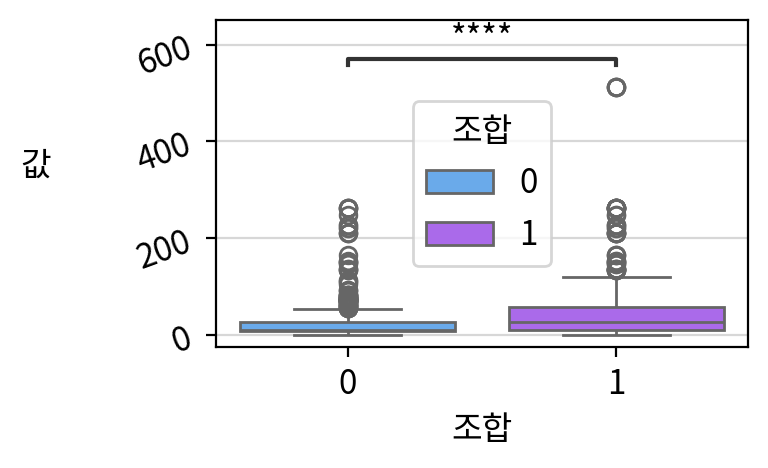

통계량  p - value  귀무가설 기각 여부  \
test                  검정 방향                                     
Mann - Whitney U test 양측    132978.000      0.000        True   
                      좌측    132978.000      0.000        True   
                      우측    132978.000      1.000       False   

                                                          결과  
test                  검정 방향                                   
Mann - Whitney U test 양측     왼쪽 집단 (0) 과 오른쪽 집단 (1) 은 차이가 난다  
                      좌측        왼쪽 집단 (0) 은 오른쪽 집단 (1) 보다 작다  
                      우측     왼쪽 집단 (0) 은 오른쪽 집단 (1) 보다 크지 않다

#### FamilySize -> Survived

y축 세우기 (단일 플롯)
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:8.100e-12 U_stat=1.615e+05
그래프를 그렸습니다


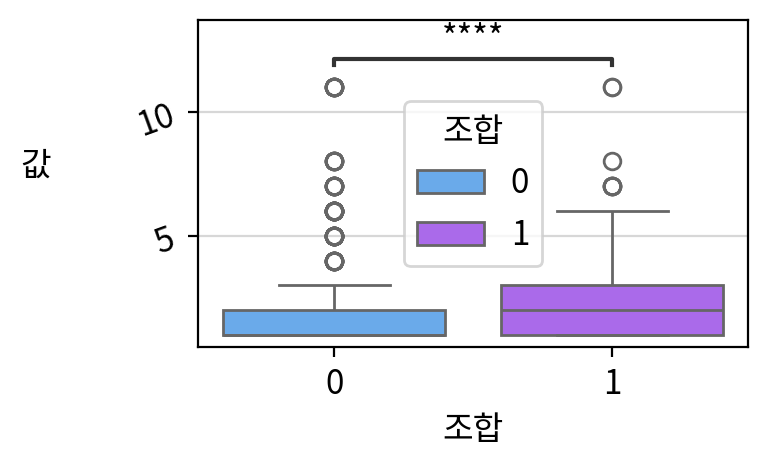

통계량  p - value  귀무가설 기각 여부  \
test                  검정 방향                                     
Mann - Whitney U test 양측    161466.000      0.000        True   
                      좌측    161466.000      0.000        True   
                      우측    161466.000      1.000       False   

                                                          결과  
test                  검정 방향                                   
Mann - Whitney U test 양측     왼쪽 집단 (0) 과 오른쪽 집단 (1) 은 차이가 난다  
                      좌측        왼쪽 집단 (0) 은 오른쪽 집단 (1) 보다 작다  
                      우측     왼쪽 집단 (0) 은 오른쪽 집단 (1) 보다 크지 않다

In [35]:
t검정_결과확인 , t검정_결과_간단확인 = my_EDA.두_개의_고유값_분석(카테고리_변환 , 종속변수 , 가로 = 400 , 세로 = 250 , palette = 'cool')

In [36]:
# 특수하게도 FamilySize 는 직접 0 과 1 에 따른 사망률 / 생존률 확인을 할 수 있다

# 직접 생존율 계산

fs_rate = 카테고리_변환.groupby('FamilySize' , observed = True)[종속변수].value_counts(normalize = True).unstack()
# unstack() 통해서 멀티 인덱스 내에 있던 Survived 부분의 0 과 1 부분을 칼럼으로 올린다

fs_rate

Survived,0,1
FamilySize,,
1,0.708,0.292
2,0.468,0.532
3,0.440,0.560
4,0.279,0.721
5,0.773,0.227
6,0.800,0.200
7,0.688,0.312
8,0.875,0.125
11,0.818,0.182


,사망률,생존률,전체 인원수
FamilySize,,,
1,0.708,0.292,790
2,0.468,0.532,235
3,0.440,0.560,159
4,0.279,0.721,43
5,0.773,0.227,22
6,0.800,0.200,25
7,0.688,0.312,16
8,0.875,0.125,8
11,0.818,0.182,11


y축 세우기 (단일 플롯)
그래프를 그렸습니다


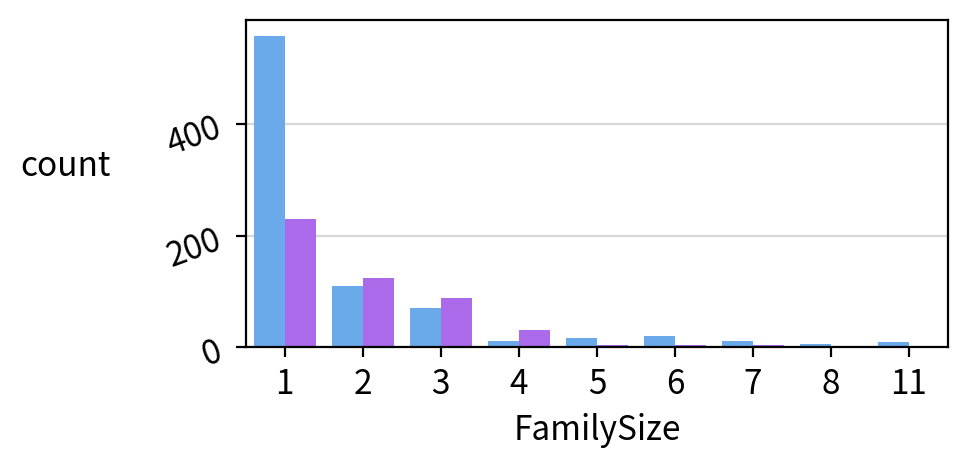

In [37]:
# fs_rate 을 꾸미고 countplot() 으로 시각화까지 ㄱㄱ

범주별분포 = fs_rate.copy()

범주별분포.columns = ['사망률' , '생존률']
범주별분포['전체 인원수'] = 카테고리_변환['FamilySize'].value_counts().sort_index()
display(범주별분포)

# 가족 규모에 따른 생존 빈도 시각화
my_plot.countplot(데이터 = 카테고리_변환 , x = 'FamilySize' , hue = 종속변수 , palette = 'cool' ,
                  가로 = 500 , 세로 = 250)

y축 세우기 (단일 플롯)
기본은 평균 값을 구하게 됩니다
그래프를 그렸습니다


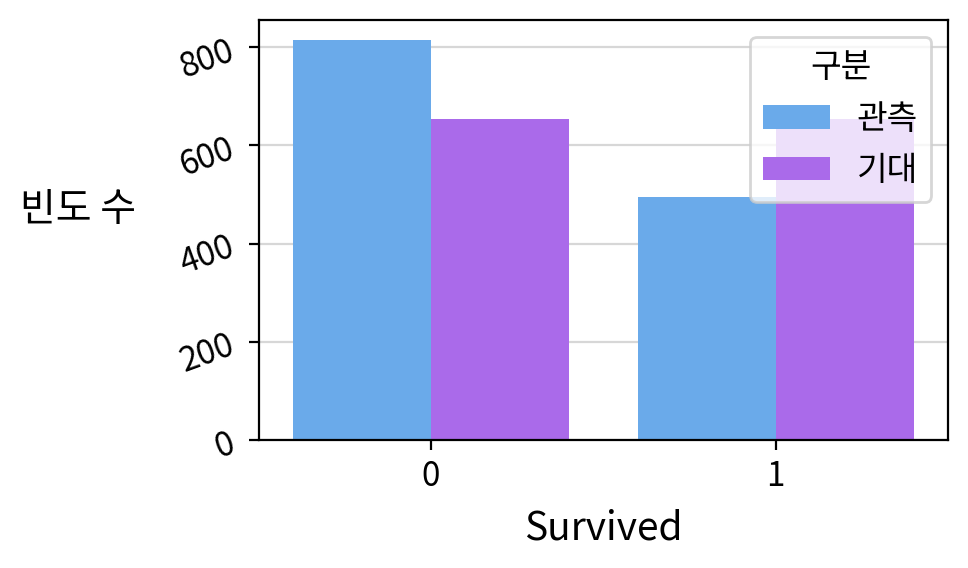

,통계량,자유도,p 값,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가정 확인,검정 방식
카이제곱 적합도 검정,78.717,1,0.000,True,True,0.245,약함,654.500,True,카이제곱 적합도 검정


y축 세우기 (단일 플롯)
합계를 기준으로 피벗 테이블이 만들어지고 요약 될 예정
색상이 채워집니다
그래프를 그렸습니다


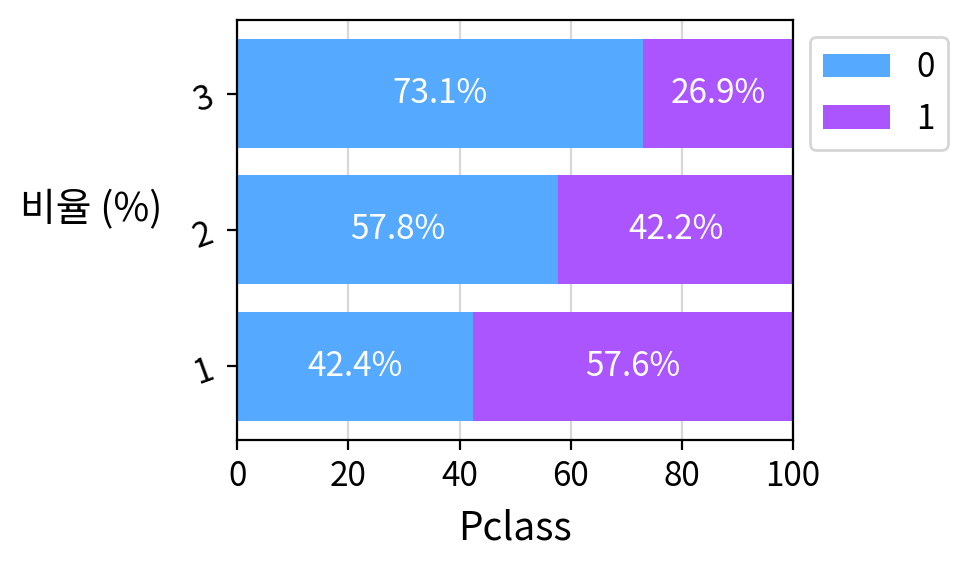

,,검정 방식,통계량 결과,자유도 결과,p값 결과,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가설 검정 만족 여부
행,열,,,,,,,,,,
Pclass,Survived,카이제곱 테스트 of independence,91.724,2,0.000,True,True,0.265,약함,104.540,True


Survived,0,1
Pclass,,
1,0.424,0.576
2,0.578,0.422
3,0.731,0.269


y축 세우기 (단일 플롯)
그래프를 그렸습니다


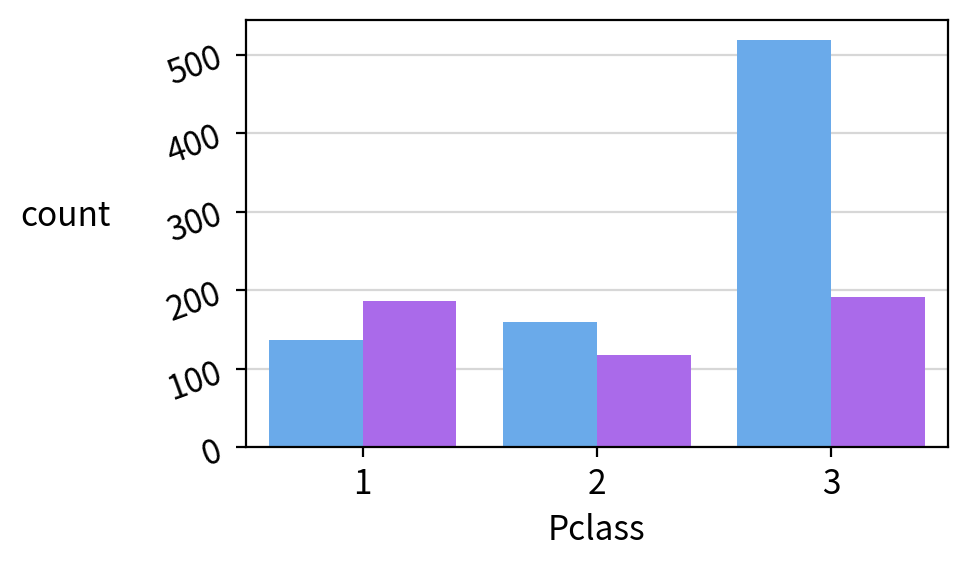

y축 세우기 (단일 플롯)
합계를 기준으로 피벗 테이블이 만들어지고 요약 될 예정
색상이 채워집니다
그래프를 그렸습니다


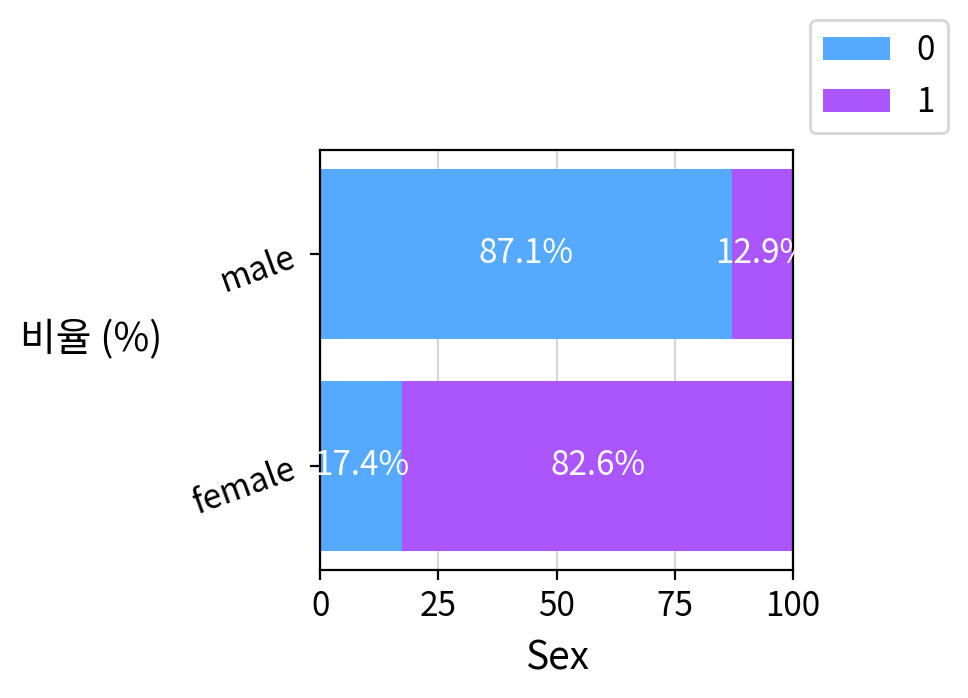

,,검정 방식,통계량 결과,자유도 결과,p값 결과,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가설 검정 만족 여부
행,열,,,,,,,,,,
Sex,Survived,카이제곱 테스트 of independence,617.313,1,0.000,True,True,0.687,강함,175.860,True


Survived,0,1
Sex,,
female,0.174,0.826
male,0.871,0.129


y축 세우기 (단일 플롯)
그래프를 그렸습니다


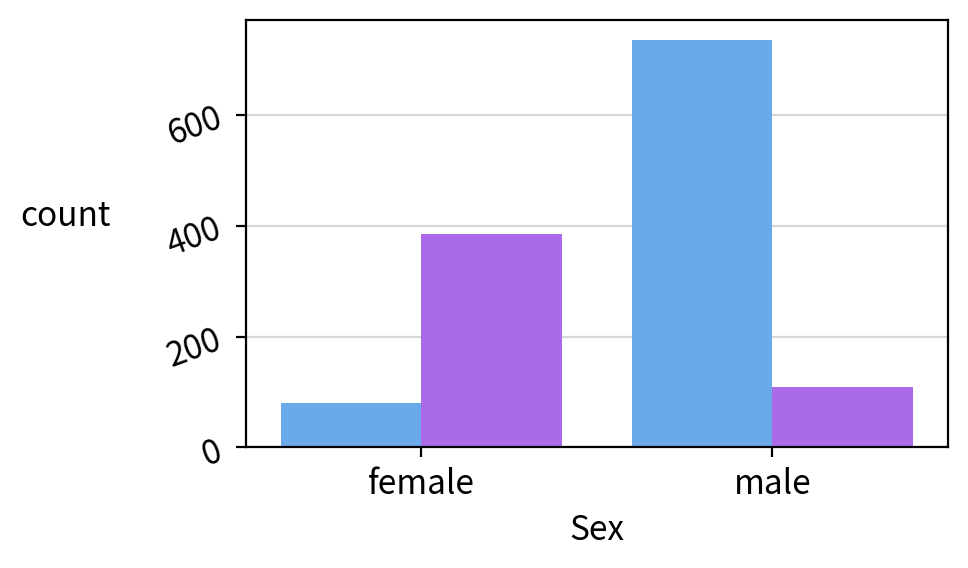

y축 세우기 (단일 플롯)
합계를 기준으로 피벗 테이블이 만들어지고 요약 될 예정
색상이 채워집니다
그래프를 그렸습니다


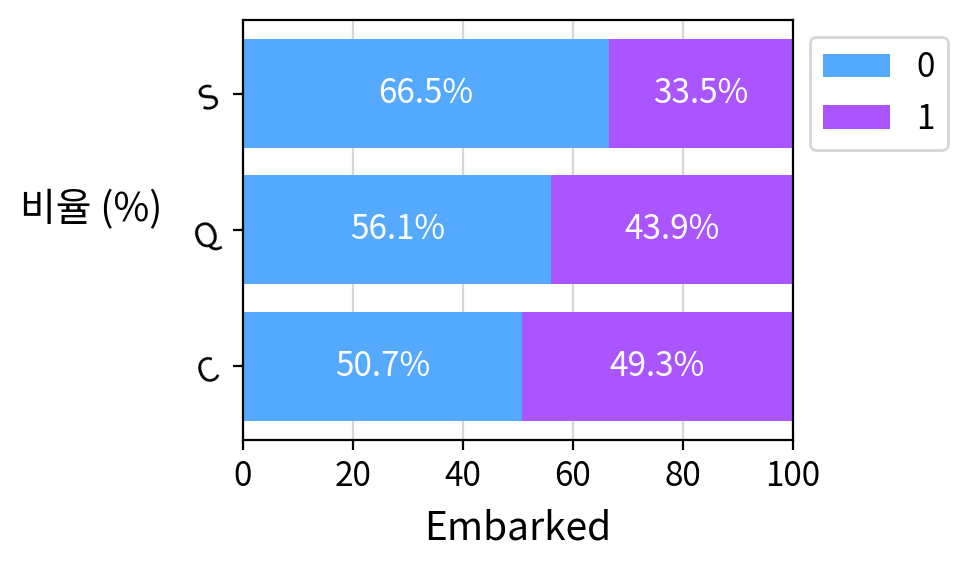

,,검정 방식,통계량 결과,자유도 결과,p값 결과,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가설 검정 만족 여부
행,열,,,,,,,,,,
Embarked,Survived,카이제곱 테스트 of independence,24.194,2,0.000,True,True,0.136,약함,46.420,True


Survived,0,1
Embarked,,
C,0.507,0.493
Q,0.561,0.439
S,0.665,0.335


y축 세우기 (단일 플롯)
그래프를 그렸습니다


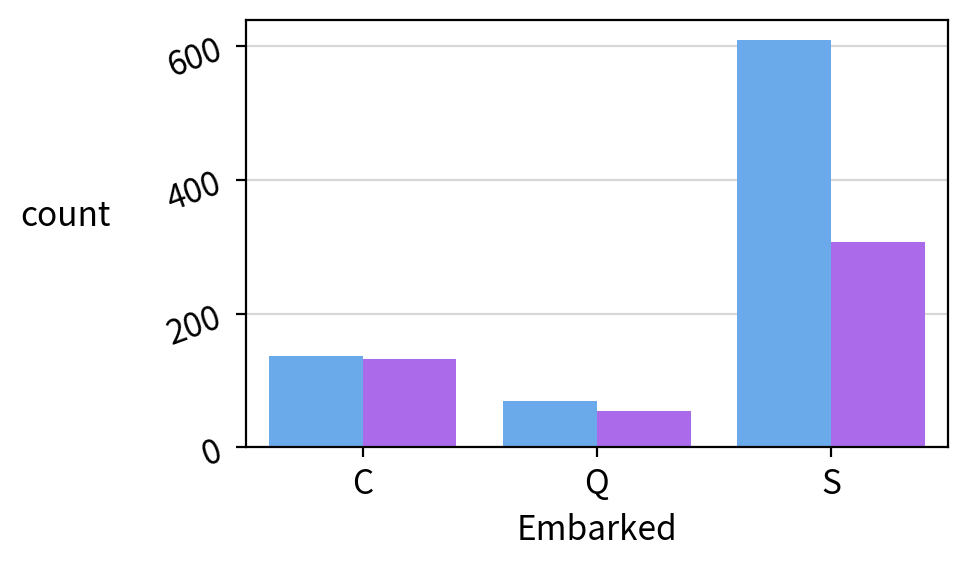

y축 세우기 (단일 플롯)
합계를 기준으로 피벗 테이블이 만들어지고 요약 될 예정
색상이 채워집니다
그래프를 그렸습니다


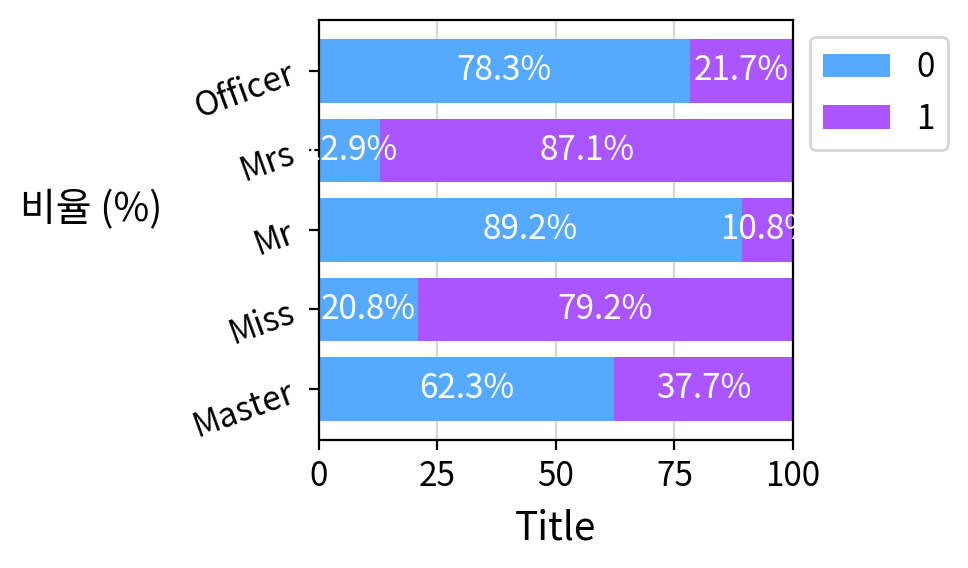

,,검정 방식,통계량 결과,자유도 결과,p값 결과,귀무가설 기각 여부,유의미한 차이 여부,효과 크기,효과 크기 (설명),기대값 최소,가설 검정 만족 여부
행,열,,,,,,,,,,
Title,Survived,카이제곱 테스트 of independence,638.384,4,0.000,True,True,0.698,강함,8.680,True


Survived,0,1
Title,,
Master,0.623,0.377
Miss,0.208,0.792
Mr,0.892,0.108
Mrs,0.129,0.871
Officer,0.783,0.217


y축 세우기 (단일 플롯)
그래프를 그렸습니다


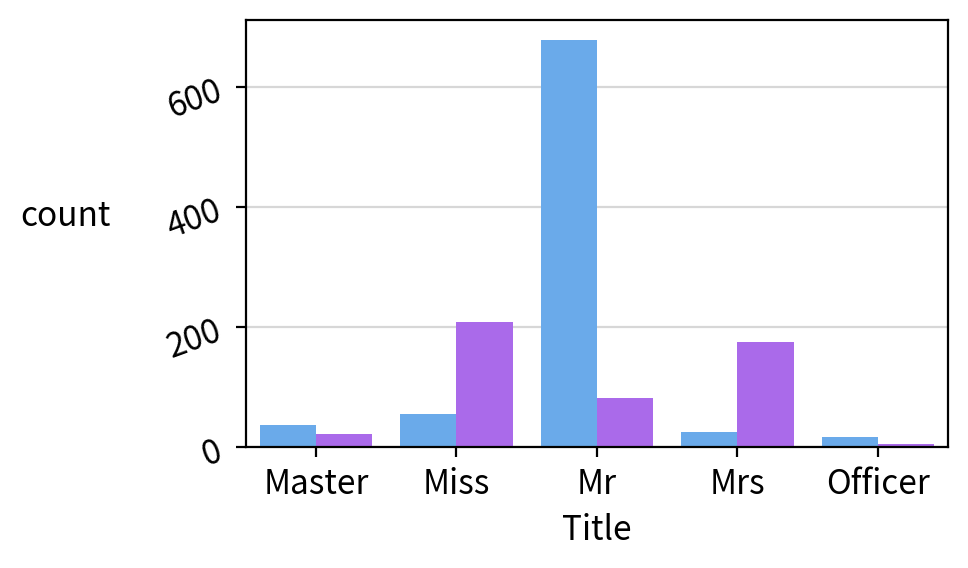

In [38]:
적합도_검정결과 , 카이제곱_결과 , 비율부분_결과 = my_EDA.카이제곱_교차분석(카테고리_변환 , 종속변수 , 가로 = 500 , 세로 = 300 , 표시옵션 = 1)

In [39]:
다중상관분석_결과 , 신호감지결과 = my_EDA.다중공산성_탐지(카테고리_변환 , 연속형_변수)

display(신호감지결과)

,Age,SibSp,Parch,Fare,FamilySize
Age,1.000,-0.102,-0.182,0.173,-0.135
SibSp,-0.102,1.000,0.438,0.446,0.848
Parch,-0.182,0.438,1.000,0.400,0.796
Fare,0.173,0.446,0.400,1.000,0.521
FamilySize,-0.135,0.848,0.796,0.521,1.000


,,검정방법,상관계수,p값,강도결과,유의미한 차이 여부,X 정규성,Y 정규성,선형 여부,이상치 여부,왜도 여부
x,y,,,,,,,,,,
SibSp,FamilySize,스피어만 (Spearman),0.848,0.000,많이 강함,True,False,False,False,True,True
Parch,FamilySize,스피어만 (Spearman),0.796,0.000,많이 강함,True,False,False,False,False,True


,최대 y,최대 상관계수,개수,columns,진단결과
x,,,,,
FamilySize,SibSp,0.848,2,"SibSp , Parch",다중공선성 의심
SibSp,FamilySize,0.848,1,FamilySize,양호
Parch,FamilySize,0.796,1,FamilySize,양호
Fare,FamilySize,0.521,0,-,양호
Age,Parch,-0.182,0,-,양호


In [41]:
my_stats.VIF계산하기(카테고리_변환)

# 무한대가 떠서 경고가 뜸

,const,Age,SibSp,Parch,Fare,FamilySize
0,1.000,22.000,1,0,7.250,2
1,1.000,38.000,1,0,71.283,2
2,1.000,26.000,0,0,7.925,1
3,1.000,35.000,1,0,53.100,2
4,1.000,35.000,0,0,8.050,1


6

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
FamilySize,inf
Parch,inf
SibSp,inf
Fare,1.119
Age,1.099
